In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

stats = device.memory_stats()
free = stats["bytes_limit"] - stats["bytes_in_use"]
print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
print(f"Free       : {free / 1024**3:.2f} GB")

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import dorito
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("amigo version:", amigo.__version__)
print("dorito version:", dorito.__version__)

NVIDIA H200
Total VRAM : 104.79 GB
In use     : 0.00 GB
Free       : 104.79 GB
64bit enabled
jax version: 0.8.3
equinox version: 0.13.7
lineax version 0.1.0
zodiax version: 0.5.0
dLux version: 0.15.0
amigo version: 0.0.10
dorito version: 0.2.0


# Loading in data

In [2]:
# Setting data path
from socket import gethostname

print(f"host name: {gethostname()}")

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/morgana2/snert/max/data/JWST/"
    cache_dir = "/Volumes/morgana2/snert/max/data/amigo_cache"
    amigo_files_path = "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10"
    output_path = "/Users/mc/outputs/GTO1200"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.10"
    output_path = "/home/dgxuser/max/outputs/GTO1200"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.10"
    output_path = "/fred/oz440/max/outputs/GTO1200"


# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False


# Quick toggle flags
plot_flag = check_script()
save_flag = check_script()

if save_flag:
    
    job_index = int(sys.argv[1])
    
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    task_id = os.environ.get("SLURM_ARRAY_TASK_ID")
    if job_id is not None and task_id is not None:
        job_id = f"{job_id}_{task_id}"
    elif job_id is None:
        from datetime import datetime
        form = "%y-%m-%d_%H-%M-%S_%f"
        now = datetime.now()
        job_id = now.strftime(form)
    print(f"Job ID: {job_id}")
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    import shutil

    shutil.copy(__file__, save_path + "/script.py")

    log_path = os.path.join(save_path, "output.txt")

    class Tee:
        def __init__(self, filename):
            self.file = open(filename, "w")
            self.stdout = sys.stdout

        def write(self, message):
            self.stdout.write(message)
            self.file.write(message)

        def flush(self):
            self.stdout.flush()
            self.file.flush()

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

else:
    save_path = None

print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-imagev2-2-0-4
Running in a notebook or interactive shell
Running in a notebook or interactive shell
Save path: None
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.10


In [3]:
# Add extra bad pixels
badpix = np.load(f"{cache_dir}/full_badpix.npy")
badpix = np.array(badpix, dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    if file[0].header["EXP_TYPE"] == "NIS_DARK":
        file["BADPIX"].data[25, 74] = 1
    return file


# Visualising metadata in a table
def summarise_files(files):
    prog_ids = []
    fnames = []
    targets = []
    filts = []
    diths = []
    ngroups = []
    time = []
    pis = []
    cals = []

    for file in files:
        header = file[0].header

        prog_ids.append(header["PROGRAM"][1:])
        fnames.append(header["FILENAME"][:25])
        targets.append(header["TARGPROP"])
        filts.append(header["FILTER"])
        diths.append(f"{header["PATT_NUM"]}/{header["NUMDTHPT"]}")
        ngroups.append(f"{header["NGROUPS"]}/{header["NINTS"]}")
        time.append(header["DATE-BEG"])
        pis.append(header["PI_NAME"])
        try:
            cals.append(header["IS_PSF"])
        except KeyError:
            cals.append("FLAT")

    df = pd.DataFrame(
        {
            "program": prog_ids,
            # "filename": fnames,
            "target": targets,
            "filter": filts,
            "dither": diths,
            "g/i": ngroups,
            "date": time,
            "PI": pis,
            "CAL": cals,
        }
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.assign(date=pd.to_datetime(df["date"]).dt.strftime("%d-%m-%Y"))

    with pd.option_context(
        "display.expand_frame_repr",
        False,
        "display.max_columns",
        None,
        "display.max_rows",
        None,
        "display.width",
        1000,
    ):
        print(df)

    # df.to_excel("cal_data.xlsx", index=False)

## Loading in data and exposures

In [4]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files
from amigo.model_fits import PointFit, SplineVisFit

# Collated validator subset
program_path = os.path.join(data_dir, "GTO1200/calslope/")
files = get_files(program_path, "nis_calslope", FILTER="F380M")

# Adding bad pixels and summarising metadata
files = [add_badpix(file) for file in files if file[0]]
summarise_files(files)

# Construct the exposures
exposures = [PointFit(file) for file in files]
# exposures = [SplineVisFIt(file) for file in files]

# _ = [f.close() for f in files]

  program     target filter dither      g/i        date              PI    CAL
0    1200  HD-218396  F380M    1/1   3/6864  03-08-2023  Vandal, Thomas  False
1    1200   HD-95086  F380M    1/1  12/9792  03-08-2023  Vandal, Thomas  False
2    1200   HD-93649  F380M    1/1   4/9215  03-08-2023  Vandal, Thomas   True


# Building model

In [5]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# Get the model
model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(static=False),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(),
    read=ReadModel(),
    # state=load_dict(amigo_files_path + "/calibration.npy"),
    # state=load_dict(amigo_files_path + "/best_state.npy"),
)

Populate from state.

In [6]:
state = load_dict(amigo_files_path + "/calibration.npy")
best_state = load_dict(amigo_files_path + "/best_state.npy")
if "jitter" in state.keys():
    state["sigma"] = state["jitter"]
# state = load_dict(amigo_files_path + "/calibration.npy")
print(best_state.keys())

for key, value in best_state.items():
    if key not in ["FF", "dark_current", "defocus", "distortion", "non_linearity", "primary_beam", "sigma", "nn_weights"]:
        continue
    if key in ["FF"]:
        continue
    model = model.set(key, value)

dict_keys(['FF', 'aberrations', 'dark_current', 'defocus', 'distortion', 'flat_coeffs', 'fluxes', 'non_linearity', 'positions', 'primary_beam', 'sigma', 'spectra', 'nn_weights'])


## Checking initial fits
Just looking at one per filter. Starting with the calibrator exposures.

In [7]:
model.params

{'aberrations': {'01200_F380M': Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float64)},
 'defocus': {'F380M': Array(0.00950618, dtype=float64),
  'F430M': Array(0.03365786, dtype=float64),
  'F480M': Array(0.0036507, dtype=float64)},
 'fluxes': {'01200_001_02_03_1': Array(5.62677756, dtype=float64),
  '01200_002_02_03_1': Array(5.01697472, dtype=float64),
  '01200_003_04_03_1': Array(5.46351121, dtype=float64)},
 'positions': {'01200_001_02_03_1': Array([ 0.34648249, -0.04248363], dtype=float64),
  '01200_002_02_03_1': Array([ 0.35872049, -0.03088231], dtype=float64),
  '01200_003_04_03_1': Array([ 0.35240006, -0.02997463], dtype=float64)},
 'spectra': {'HD-218396_F380M': Ar

File 01200_002_02_03_1
Star HD-95086
Filter F380M
nints 9792
ngroups 12



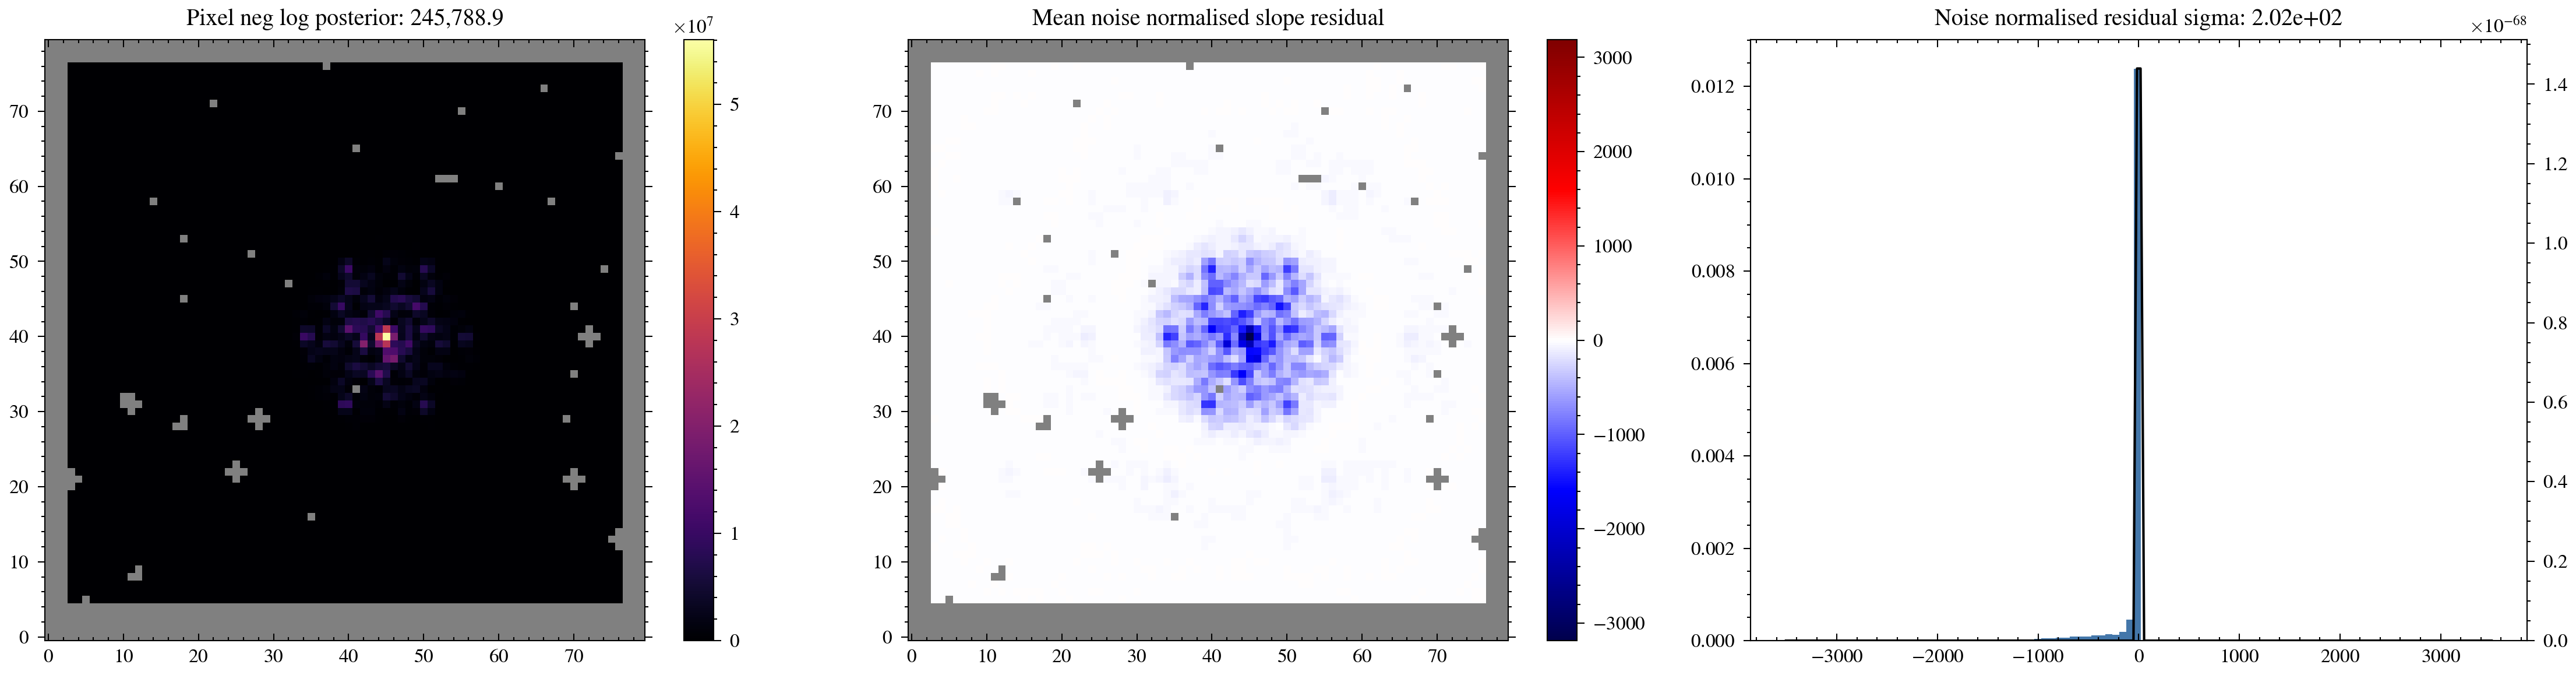

File 01200_001_02_03_1
Star HD-218396
Filter F380M
nints 6864
ngroups 3



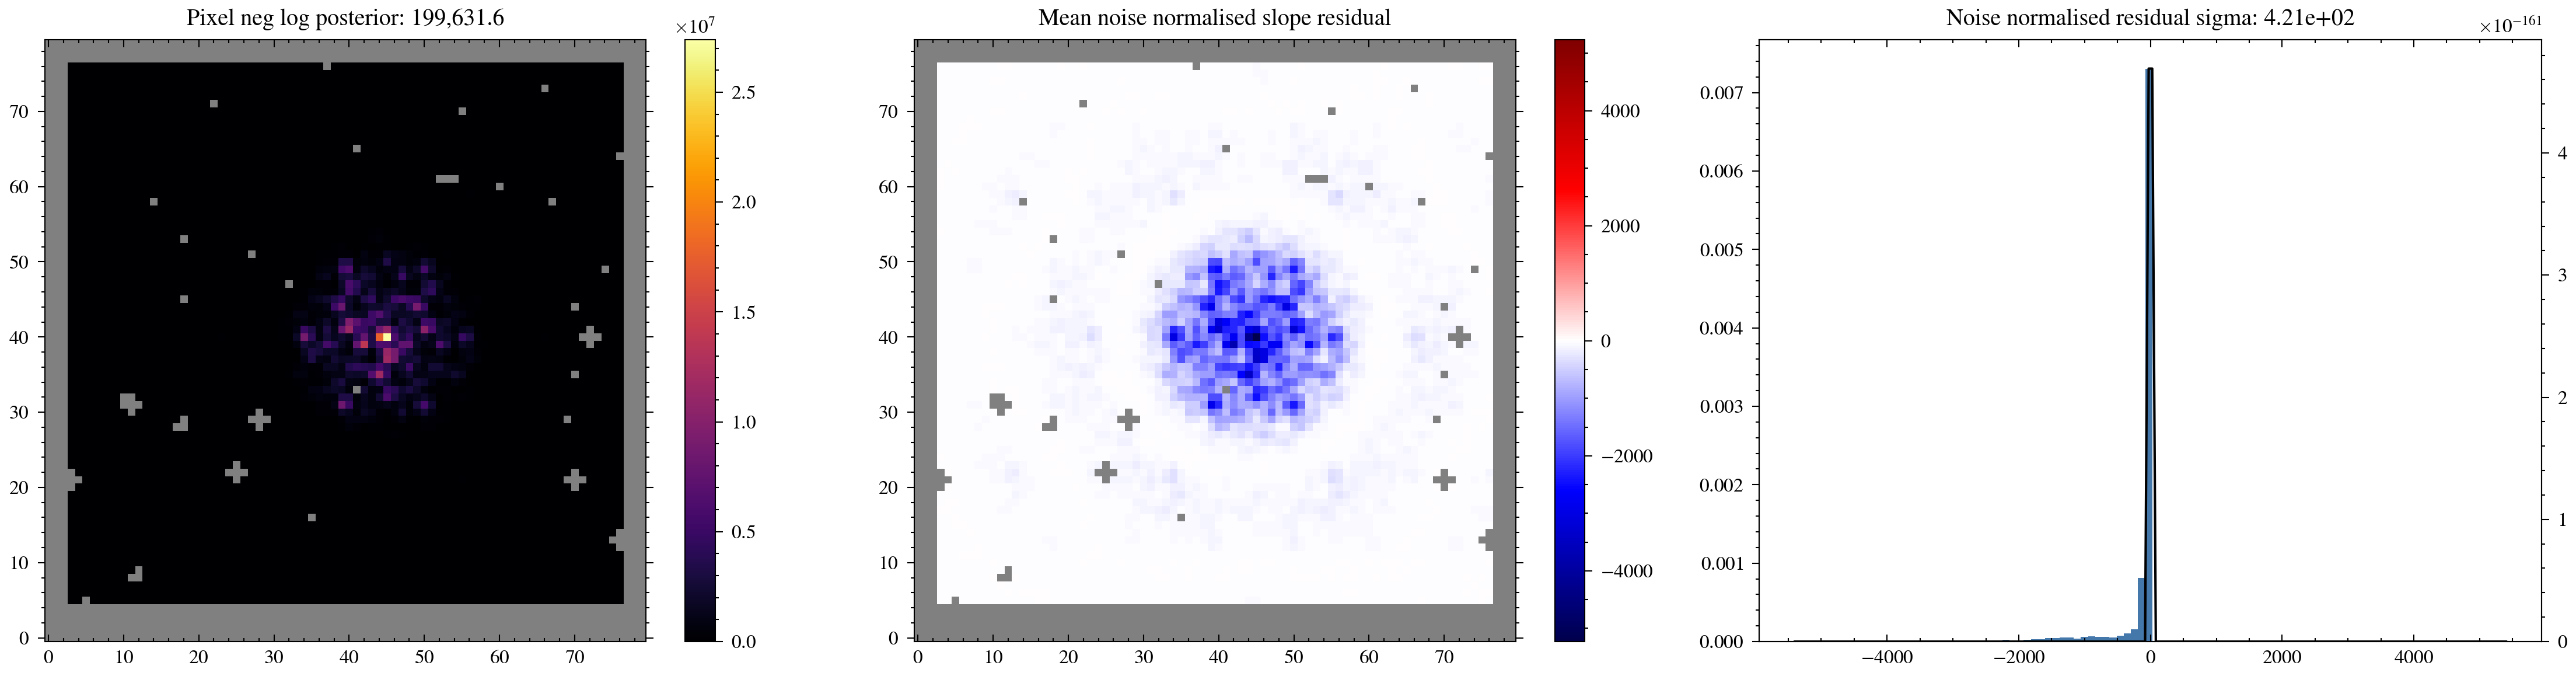

File 01200_003_04_03_1
Star HD-93649
Filter F380M
nints 9215
ngroups 4



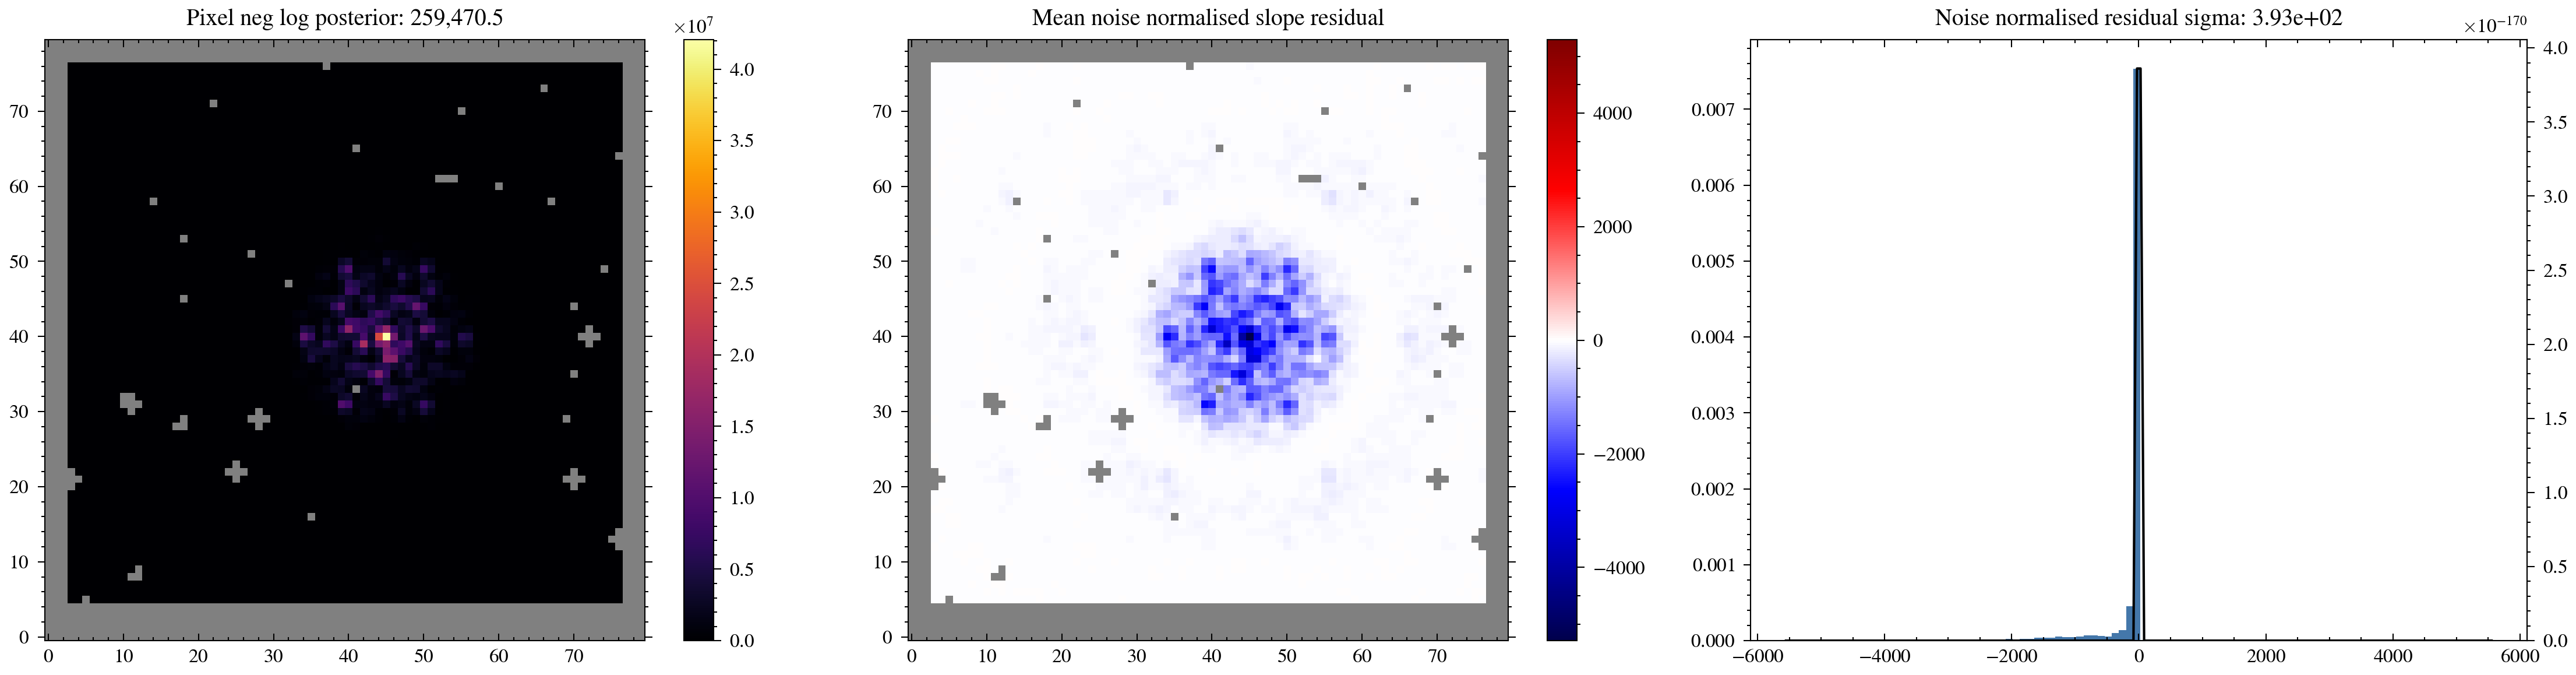

In [8]:
from amigo.plotting import summarise_fit


if True:
# if plot_flag:
    if save_flag:
        this_save_path = os.path.join(save_path, "init")
        os.mkdir(this_save_path)
    else:
        this_save_path = None
    for exp in exposures:
        exp.print_summary()
        summarise_fit(model, exp, save_path=this_save_path)

# Optimisation

## Setup
For the neural network training we want to use a custom learning rate warmup and a temperature decay, so we will have to modify a lot of the statistical functions of amigo to be able to handle this

In [9]:
from retrain_fns import (
    loss_fn,
    args_fn,
    looper_fn,
    grads_fn,
    aux_fn,
    ff_reg,
    nl_reg,
    temp_decay,
    cosine_warmup,
)


def norm_fn(model_params, args):
    """
    Normalisation function.
    """

    # spectra clipping
    if hasattr(model_params, "spectra"):
        spectra = model_params.spectra
        clip_fn = lambda x: np.clip(x, a_min=-0.8, a_max=0.8)
        spectra = jax.tree.map(clip_fn, spectra)
        model_params = model_params.set("spectra", spectra)

    return model_params, args


Instantiating trainer class and updating fishers.

In [10]:
from amigo.calibration import Trainer
from amigo.fitting import sgd, adam

recalculate_flag = False
epochs = 50

optimisers = {
    "fluxes": sgd(1e-2, 0),
    "positions": sgd(1e-2, 2),
    "aberrations": sgd(1e-3, 5),
#     "spectra": sgd(1e-3, 20),
}

# Trainer class
trainer = Trainer(
    norm_fn=norm_fn,
    cache=cache_dir,
)

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

trainer = trainer.update_fishers(
    linear_model,
    exposures,
    parameters=list(optimisers.keys()),
    recalculate=recalculate_flag,
)

# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x
model = jtu.map(fn, model)

# Train the model
result = trainer.train(
    model=model,
    optimisers=optimisers,
    epochs=epochs,
    batches=exposures, 
)

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Compiling Loss function...


W0602 02:53:59.991422   10681 cuda_command_buffer.cc:768] Retry CUDA graph instantiation after OOM error
E0602 02:54:00.002801   10681 pjrt_stream_executor_client.cc:2091] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Underlying backend ran out of memory trying to instantiate command buffer with 60 (total of 0 alive graphs in the process). You can try to (a) Give more memory to the driver by reducing XLA_CLIENT_MEM_FRACTION (b) Disable command buffers with 'XLA_FLAGS=--xla_gpu_enable_command_buffer=' (empty set). Original error: Failed to instantiate CUDA graph: CUDA_ERROR_OUT_OF_MEMORY: out of memory


JaxRuntimeError: RESOURCE_EXHAUSTED: Underlying backend ran out of memory trying to instantiate command buffer with 60 (total of 0 alive graphs in the process). You can try to (a) Give more memory to the driver by reducing XLA_CLIENT_MEM_FRACTION (b) Disable command buffers with 'XLA_FLAGS=--xla_gpu_enable_command_buffer=' (empty set). Original error: Failed to instantiate CUDA graph: CUDA_ERROR_OUT_OF_MEMORY: out of memory

Training.

Plotting the results of that fit!

In [ ]:
amigo.plotting.plot(result.history, save_path=save_path)
amigo.plotting.plot_losses(result.losses[0], 0)

for exp in exposures:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp, save_path=this_save_path)